In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [3]:
# data = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

# data.head()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb
import lightgbm as lgb
import random
import os

In [5]:
def set_seed(seed: int = 42) -> None:
    """Sets random seed for reproducibility across different libraries."""
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed set to: {seed}")

In [6]:
def load_data(file_path: str = "/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv") -> pd.DataFrame:
    """Loads the credit card dataset from a CSV file."""
    try:
        df = pd.read_csv(file_path)
        return df
    except FileNotFoundError:
        print(f"Error: The file at {file_path} was not found.")
        return pd.DataFrame()

In [7]:
def display_dataset_info(df: pd.DataFrame) -> None:
    """Displays key information about the dataset: shape, columns, and class distribution."""
    if df.empty:
        return

    # 1. Shape and Columns
    print("-" * 30)
    print(f"Dataset Shape: {df.shape}")
    print(f"Column Names: {df.columns.tolist()}")
    print("-" * 30)

    # 2. Class Distribution (Counts + Percentage)
    class_counts = df['Class'].value_counts()
    class_percentages = df['Class'].value_counts(normalize=True) * 100
    
    print("Class Distribution:")
    dist_df = pd.DataFrame({
        'Count': class_counts,
        'Percentage (%)': class_percentages.map("{:.4f}%".format)
    })
    print(dist_df)
    print("-" * 30)

    # 3. Missing Values
    missing_count = df.isnull().sum().sum()
    print(f"Total missing values: {missing_count}")
    if missing_count > 0:
        print(df.isnull().sum()[df.isnull().sum() > 0])
    print("-" * 30)

In [8]:
# Load dataset
DATA_PATH = "/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv"
df = load_data(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df[df['Class'] == 1]['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [10]:
set_seed(42)

    # Perform initial check
if not df.empty:
    display_dataset_info(df)

Random seed set to: 42
------------------------------
Dataset Shape: (284807, 31)
Column Names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
------------------------------
Class Distribution:
        Count Percentage (%)
Class                       
0      284315       99.8273%
1         492        0.1727%
------------------------------
Total missing values: 0
------------------------------


/tmp/ipykernel_55/158660733.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette='viridis')


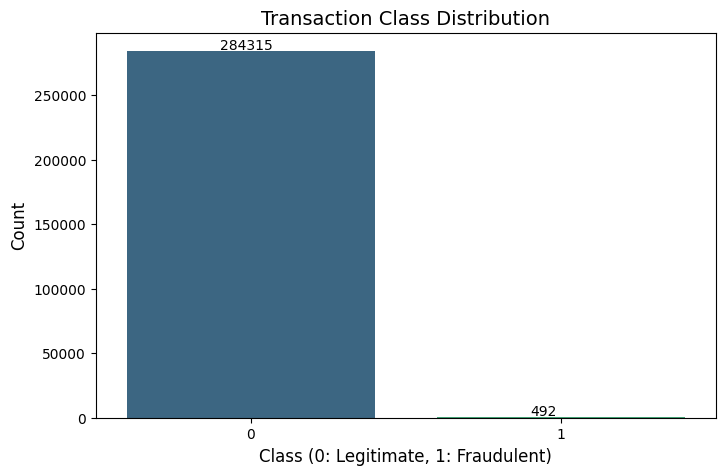

In [11]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Transaction Class Distribution', fontsize=14)
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding annotations for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 1000))

plt.show()


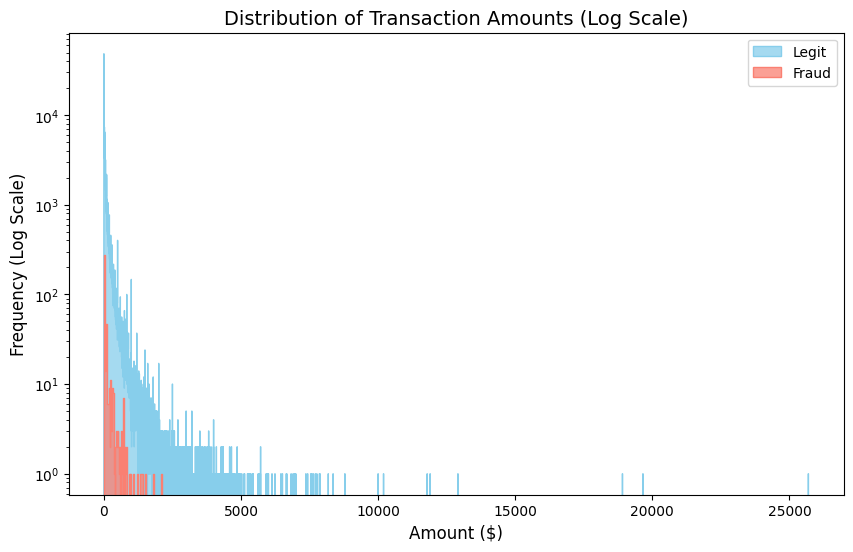

In [12]:
plt.figure(figsize=(10, 6))

# Plotting with log scale on the x-axis to handle skewness
sns.histplot(df[df['Class'] == 0]['Amount'], color='skyblue', label='Legit', kde=False, element="step")
sns.histplot(df[df['Class'] == 1]['Amount'], color='salmon', label='Fraud', kde=False, element="step")

plt.yscale('log') # Use log scale for vertical axis to see small fraud counts
plt.title('Distribution of Transaction Amounts (Log Scale)', fontsize=14)
plt.xlabel('Amount ($)', fontsize=12)
plt.ylabel('Frequency (Log Scale)', fontsize=12)
plt.legend()
plt.show()


/tmp/ipykernel_55/2156595525.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class'] == 0]['Time'], label='Legit', shade=True, color='skyblue')
/tmp/ipykernel_55/2156595525.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud', shade=True, color='salmon')


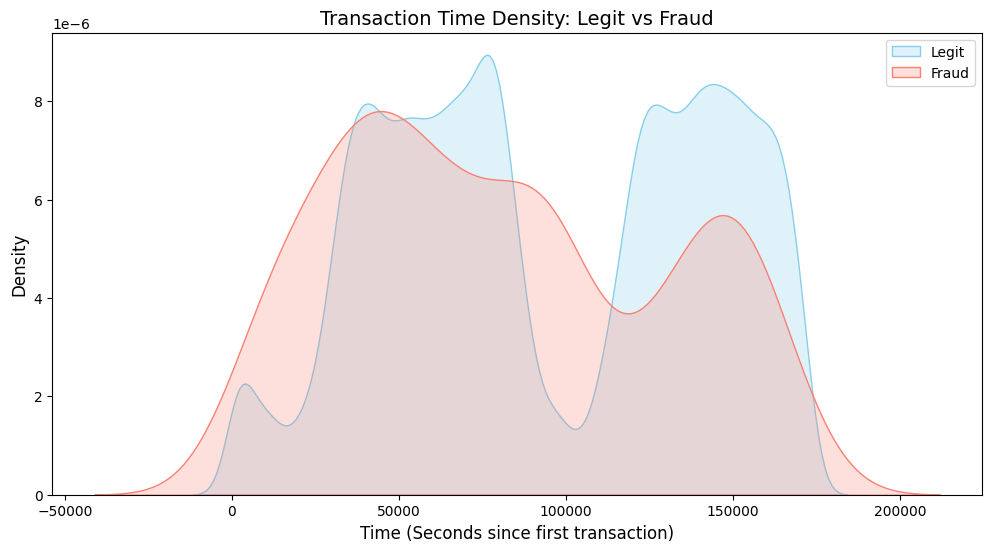

In [13]:
plt.figure(figsize=(12, 6))

sns.kdeplot(df[df['Class'] == 0]['Time'], label='Legit', shade=True, color='skyblue')
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud', shade=True, color='salmon')

plt.title('Transaction Time Density: Legit vs Fraud', fontsize=14)
plt.xlabel('Time (Seconds since first transaction)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()


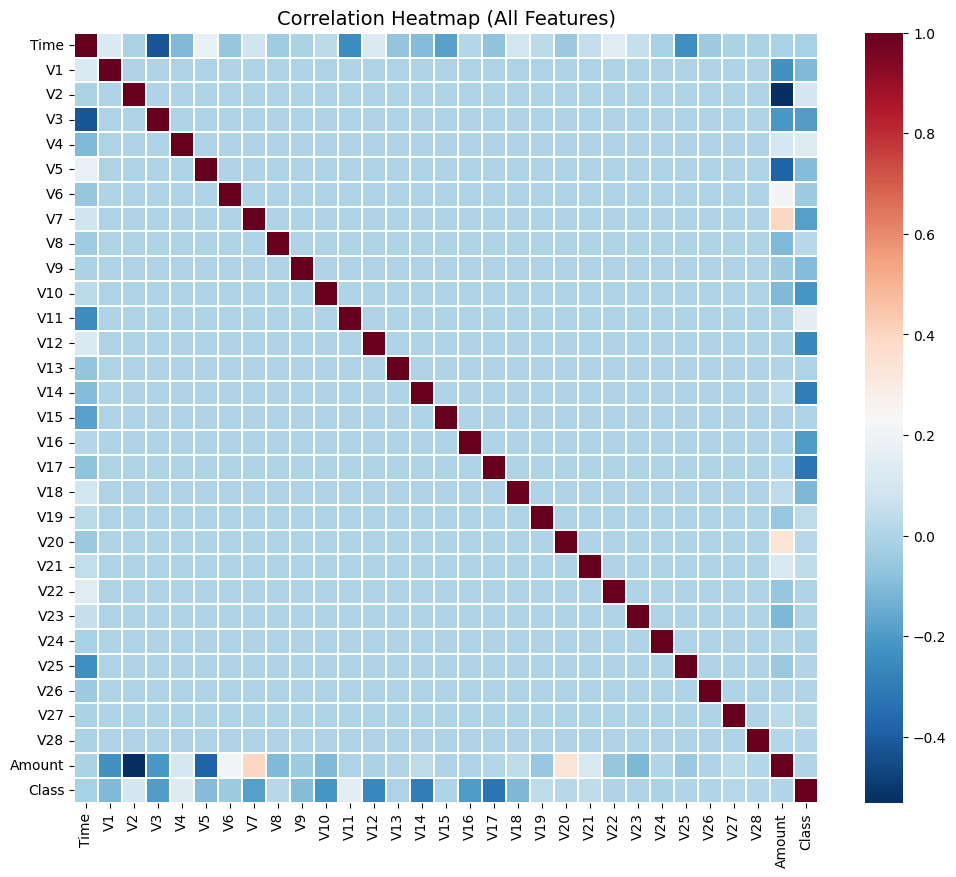


Top Correlations with Class (Target):
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
Name: Class, dtype: float64
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [14]:
# Calculate correlation matrix
corr = df.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='RdBu_r', annot=False, linewidths=0.1, fmt='.2f')
plt.title('Correlation Heatmap (All Features)', fontsize=14)
plt.show()

# Optional: Print top correlations with Class
print("\nTop Correlations with Class (Target):")
print(corr['Class'].sort_values(ascending=False).head(5))
print(corr['Class'].sort_values(ascending=False).tail(5))


## Feature Engineering
>Fraud often follows human patterns. For example, fraudulent activity might spike at 3 AM when people are asleep and less likely to "see" a notification. By creating an Hour feature, we give the model a "human" dimension to look at.
> ```The Amount column is typically highly skewed. Most transactions are small (e.g., $10), but a few are massive ($20,000). If we use a raw $20,000 value, the model might overreact to it, treating it as a massive outlier that pulls the average away from the "normal" data. ```
> ``` Log transformation "squashes" large values while keeping small values distinct. log1p calculates log(1 + x), which is mathematically safer than standard log because it prevents errors if a transaction amount is $0.```

In [15]:
# 1. Create 'Hour' feature from Time (seconds)
df['Hour'] = (df['Time'] // 3600) % 24

# 2. Create Log Transform of Amount (log1p handles 0 amounts safely)
df['Amount_Log'] = np.log1p(df['Amount'])

print("New Features Created:")
print(df[['Time', 'Hour', 'Amount', 'Amount_Log']].head())


New Features Created:
   Time  Hour  Amount  Amount_Log
0   0.0   0.0  149.62    5.014760
1   0.0   0.0    2.69    1.305626
2   1.0   0.0  378.66    5.939276
3   1.0   0.0  123.50    4.824306
4   2.0   0.0   69.99    4.262539


In [16]:
from sklearn.preprocessing import StandardScaler

# Scaling initialization (Logic moved to next cell to be performed AFTER split)
print("StandardScaler ready. Scaling will be performed after the train-test split to prevent data leakage.")


StandardScaler ready. Scaling will be performed after the train-test split to prevent data leakage.


In [17]:
from sklearn.model_selection import train_test_split

# 1. Define X and y
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Essential for imbalanced datasets
)

# 3. Scaling (Scaling AFTER split to avoid data leakage)
scaler = StandardScaler()

# We scale Time, Amount, Hour, and Amount_Log
cols_to_scale = ['Time', 'Amount', 'Hour', 'Amount_Log']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("-" * 30)
print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}")
print("-" * 30)
print("Scaling complete for 'Time', 'Amount', 'Hour', and 'Amount_Log'.")
print("Fraud distribution in Training set:")
print(y_train.value_counts(normalize=True))


------------------------------
Training Set Shape: (227845, 32)
Testing Set Shape:  (56962, 32)
------------------------------
Scaling complete for 'Time', 'Amount', 'Hour', and 'Amount_Log'.
Fraud distribution in Training set:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64


# Training the Model
We initialize and fit the model using the training data.

In [18]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize LogReg with balanced class weights
# We increase max_iter to ensure convergence
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 2. Train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression training complete.")


Logistic Regression training complete.


## Evaluation and Metrics
This block calculates all requested metrics. For fraud detection, Recall is often the most important metric because missing a single fraud case (False Negative) is much more expensive than a false alarm.



In [19]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# 1. Get predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# 2. Calculate Metrics
metrics = {
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
}

# 3. Print Results in a structured way
print("-" * 30)
print("BASELINE LOGISTIC REGRESSION RESULTS")
print("-" * 30)
for metric, value in metrics.items():
    print(f"{metric:12}: {value:.4f}")
print("-" * 30)

# 4. Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual Legit', 'Actual Fraud'], columns=['Pred Legit', 'Pred Fraud'])
display(cm_df)

# 5. Full Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


------------------------------
BASELINE LOGISTIC REGRESSION RESULTS
------------------------------
Precision   : 0.0563
Recall      : 0.9082
F1-Score    : 0.1060
ROC-AUC     : 0.9733
------------------------------

Confusion Matrix:


,Pred Legit,Pred Fraud
Actual Legit,55371,1493
Actual Fraud,9,89



Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962



To move beyond the baseline, we will now implement two powerful ensemble models: Random Forest and XGBoost. These models are better at capturing non-linear relationships between the V1-V28 features.

## Helper Function for Model Comparison
This function will store our results in a dictionary so we can easily build a comparison table at the end.

In [20]:
results = {}

def evaluate_and_store(model_name, model, X_test, y_test):
    """Predicts, evaluates, and stores results for comparison."""
    # Get predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    res = {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    }
    
    # Store in global results
    results[model_name] = res
    
    print(f"Metrics for {model_name}:")
    for k, v in res.items():
        print(f"  {k:10}: {v:.4f}")
    print("-" * 30)

# Store the already trained Logistic Regression results
# (Assuming metrics from Cell 15 were stored in a dict called 'metrics')
results["Logistic Regression"] = {
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
}


## Random Forest (Bagging)
Random Forest builds many independent trees and averages them. We use class_weight='balanced' to handle the rarity of fraud cases

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
# We limit max_depth to prevent overfitting and speed up training
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1 # Use all available CPU cores
)

# Train
print("Training Random Forest (this may take a minute)...")
rf_model.fit(X_train, y_train)

# Evaluate
evaluate_and_store("Random Forest", rf_model, X_test, y_test)


Training Random Forest (this may take a minute)...
Metrics for Random Forest:
  Precision : 0.8081
  Recall    : 0.8163
  F1-Score  : 0.8122
  ROC-AUC   : 0.9831
------------------------------


## XGBoost (Boosting)
XGBoost builds trees sequentially, where each new tree tries to correct the errors of the previous ones. We use scale_pos_weight to focus on fraud cases.



In [22]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight: sum(neg) / sum(pos)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# Evaluate
evaluate_and_store("XGBoost", xgb_model, X_test, y_test)


Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:06:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Metrics for XGBoost:
  Precision : 0.5312
  Recall    : 0.8673
  F1-Score  : 0.6589
  ROC-AUC   : 0.9740
------------------------------


## Model Fine-tuning

We will perform hyperparameter tuning on the core models (varying n_estimators, max_depth, learning_rate, etc. systematically, not just picking defaults)



In [ ]:
# ─────────────────────────────────────────────────────────────
# HYPERPARAMETER TUNING HELPER
# ─────────────────────────────────────────────────────────────
# To add a new model: define its param_grid below and call
# tune_model(model, param_grid, X_train, y_train).
# The returned best_estimator is a drop-in for any model variable
# e.g. rf_model, xgb_model, lgb_model.
# ─────────────────────────────────────────────────────────────

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


def tune_model(model, param_grid, X_train, y_train, cv=3, scoring='f1', verbose=1):
    """
    Runs GridSearchCV on a given model and parameter grid.
    Returns the best estimator found.

    Args:
        model      : Uninitialised or default sklearn-compatible model.
        param_grid : Dict of hyperparameter names to lists of values to search.
        X_train    : Training features.
        y_train    : Training labels.
        cv         : Number of cross-validation folds (default 3, keeps runtime reasonable).
        scoring    : Metric to optimise (default 'f1', suitable for imbalanced data).
        verbose    : Verbosity level passed to GridSearchCV.

    Returns:
        best_estimator : The model retrained on full training data with best params.
        best_params    : Dict of the winning hyperparameters (printed for logging).
    """
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=verbose
    )
    grid_search.fit(X_train, y_train)

    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best CV {scoring.upper()} Score: {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_, grid_search.best_params_


# ── Random Forest tuning ──────────────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [8, 10, 15],
    'class_weight': ['balanced']
}

print("Tuning Random Forest...")
rf_model, rf_best_params = tune_model(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    X_train, y_train
)

evaluate_and_store("RandomForest (Tuned)", rf_model, X_test, y_test)

# ── XGBoost tuning ────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [4, 5, 7],
    'learning_rate':   [0.05, 0.1],
    'scale_pos_weight': [scale_pos_weight]
}

print("Tuning XGBoost...")
xgb_model, xgb_best_params = tune_model(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    xgb_param_grid,
    X_train, y_train
)

evaluate_and_store("XGBoost (Tuned)", xgb_model, X_test, y_test)  # <-- added


# ─────────────────────────────────────────────────────────────
# END TUNING BLOCK
# Future models: copy the pattern above, define a param_grid,
# call tune_model(), and pass the returned model to evaluate_and_store().
# ─────────────────────────────────────────────────────────────

## Final Model Comparison
Finally, we display all our results in a single table to see which model performed best

In [23]:
# Convert the results dictionary to a DataFrame for clean visualization
comparison_df = pd.DataFrame(results).T

# Highlight the best scores for each metric
print("MODELS COMPARISON SUMMARY")
display(comparison_df.style.highlight_max(axis=0, color='lightgreen'))

# Quick tip: For fraud detection, look for the model that balances 
# high Recall (catching fraud) without destroying Precision (too many false alarms).


MODELS COMPARISON SUMMARY


,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.056258,0.908163,0.105952,0.973278
Random Forest,0.808081,0.816327,0.812183,0.983143
XGBoost,0.531250,0.867347,0.658915,0.973960


## Import Imbalance-Learn Components + Strategy 1 - Baseline (No Resampling)

In [24]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline # Note: Use imblearn's Pipeline to avoid leakage

# Results storage for the sampling comparison
resampling_results = {}

# 1. Initialize standard XGBoost
xgb_standard = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)

# 2. Train on original training data
xgb_standard.fit(X_train, y_train)

# 3. Evaluate
y_pred = xgb_standard.predict(X_test)
resampling_results['Baseline (No Resampling)'] = {
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
}


## Strategy 2 - SMOTE (Oversampling)
SMOTE creates "synthetic" fraud cases by interpolating between existing ones. This teaches the model the "shape" of the fraud class.



In [25]:
# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Apply ONLY to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3. Train on Oversampled data
xgb_smote = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
xgb_smote.fit(X_train_smote, y_train_smote)

# 4. Evaluate (on original, untouched test data)
y_pred_smote = xgb_smote.predict(X_test)
resampling_results['SMOTE (Oversampling)'] = {
    'Precision': precision_score(y_test, y_pred_smote),
    'Recall': recall_score(y_test, y_pred_smote),
    'F1-Score': f1_score(y_test, y_pred_smote)
}

print(f"SMOTE: Increased training samples from {len(X_train)} to {len(X_train_smote)}")


SMOTE: Increased training samples from 227845 to 454902


## Strategy 3 - Random Undersampling
This strategy removes legitimate transactions until the classes are balanced. It is extremely fast but "throws away" a lot of data.

In [26]:
# 1. Initialize Undersampler
rus = RandomUnderSampler(random_state=42)

# 2. Apply ONLY to training data
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# 3. Train on Undersampled data
xgb_rus = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
xgb_rus.fit(X_train_rus, y_train_rus)

# 4. Evaluate
y_pred_rus = xgb_rus.predict(X_test)
resampling_results['Random Undersampling'] = {
    'Precision': precision_score(y_test, y_pred_rus),
    'Recall': recall_score(y_test, y_pred_rus),
    'F1-Score': f1_score(y_test, y_pred_rus)
}

print(f"Undersampling: Reduced training samples from {len(X_train)} to {len(X_train_rus)}")


Undersampling: Reduced training samples from 227845 to 788


In [27]:
# Convert to DataFrame
sampling_comparison_df = pd.DataFrame(resampling_results).T

print("RE-SAMPLING STRATEGY COMPARISON")
display(sampling_comparison_df.style.highlight_max(axis=0, color='lightblue'))


RE-SAMPLING STRATEGY COMPARISON


,Precision,Recall,F1-Score
Baseline (No Resampling),0.873563,0.775510,0.821622
SMOTE (Oversampling),0.672000,0.857143,0.753363
Random Undersampling,0.035033,0.918367,0.067492


## Training the Isolation Forest
We train the model on the training features X_train without providing the labels y_train. This makes it a truly unsupervised approach.



In [28]:

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
# 1. Initialize the Isolation Forest
# contamination: estimated % of outliers. We'll use 0.0017 (0.17%) based on our EDA.
iso_forest = IsolationForest(
    n_estimators=100, 
    max_samples='auto', 
    contamination=0.0017, 
    random_state=42,
    n_jobs=-1
)
# 2. Train on X_train only (Unsupervised)
print("Training Isolation Forest...")
iso_forest.fit(X_train)

Training Isolation Forest...


IsolationForest(contamination=0.0017, n_jobs=-1, random_state=42)

In [29]:
# 1. Get raw anomaly scores from the decision function
# Lower values indicate more anomalous behavior
raw_scores = iso_forest.decision_function(X_test)

# 2. Normalize to [0, 1] using MinMaxScaler
# We flip the scores (multiply by -1) so that "high score = high anomaly"
mms = MinMaxScaler()
anomaly_scores = mms.fit_transform((-raw_scores).reshape(-1, 1)).flatten()

# Add to a temporary DataFrame for comparison
test_results = pd.DataFrame({
    'True_Class': y_test,
    'Anomaly_Score': anomaly_scores
})

print("Anomaly mapping complete.")
print(test_results.head())


Anomaly mapping complete.
        True_Class  Anomaly_Score
263020           0       0.129859
11378            0       0.331009
147283           0       0.536216
219439           0       0.072594
36939            0       0.259059


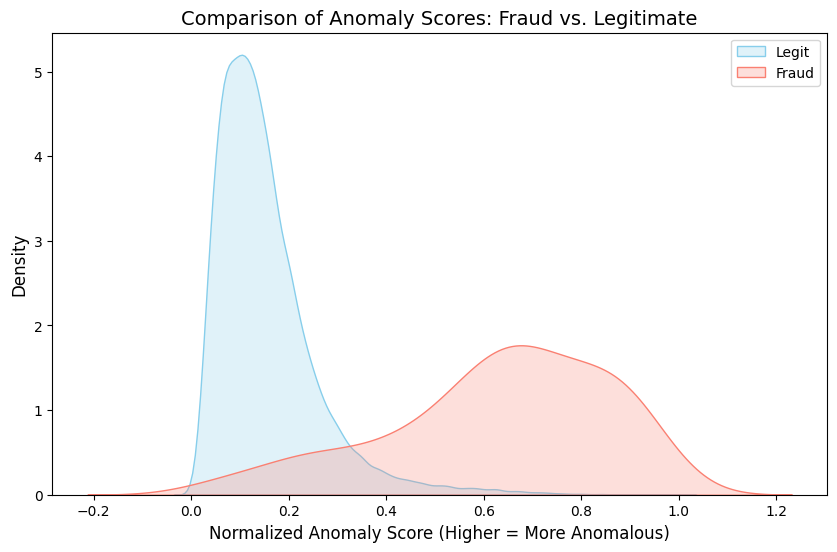


Mean Anomaly Scores by Class:
True_Class
0    0.154281
1    0.630105
Name: Anomaly_Score, dtype: float64


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting distribution of scores for both classes
sns.kdeplot(data=test_results[test_results['True_Class'] == 0], x='Anomaly_Score', label='Legit', fill=True, color='skyblue')
sns.kdeplot(data=test_results[test_results['True_Class'] == 1], x='Anomaly_Score', label='Fraud', fill=True, color='salmon')

plt.title('Comparison of Anomaly Scores: Fraud vs. Legitimate', fontsize=14)
plt.xlabel('Normalized Anomaly Score (Higher = More Anomalous)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

# Print mean scores for numerical comparison
print("\nMean Anomaly Scores by Class:")
print(test_results.groupby('True_Class')['Anomaly_Score'].mean())


In [31]:
from sklearn.preprocessing import MinMaxScaler

# 1. Normalize XGBoost Probabilities
# We already have y_pred_proba_xgb from our XGBoost cell
scaler_xgb = MinMaxScaler()
prob_xgb = scaler_xgb.fit_transform(xgb_model.predict_proba(X_test)[:, 1].reshape(-1, 1)).flatten()

# 2. Normalize Isolation Forest Anomaly Scores
# (Already done in previous cell, but re-aligning here for clarity)
prob_iso = anomaly_scores # From Cell 26

# Prepare a results dataframe
risk_df = pd.DataFrame({
    'True_Class': y_test,
    'XGB_Prob': prob_xgb,
    'ISO_Score': prob_iso
})


In [32]:
from sklearn.metrics import f1_score

best_f1 = 0
best_alpha = 0

print("Tuning Alpha/Beta Weights:")
# Iterate through possible values for Alpha (weight of XGBoost)
for alpha in np.linspace(0, 1, 11):
    beta = 1 - alpha
    
    # Calculate Hybrid Risk Score
    combined_score = (alpha * risk_df['XGB_Prob']) + (beta * risk_df['ISO_Score'])
    
    # Simple binary prediction (Score > 0.5 = Fraud) to evaluate
    y_pred_temp = (combined_score > 0.5).astype(int)
    current_f1 = f1_score(y_test, y_pred_temp)
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_alpha = alpha

print(f"Optimal Alpha: {best_alpha:.1f}")
print(f"Optimal Beta: {1 - best_alpha:.1f}")
print(f"Best F1 Score achieved: {best_f1:.4f}")


Tuning Alpha/Beta Weights:
Optimal Alpha: 0.5
Optimal Beta: 0.5
Best F1 Score achieved: 0.7478


In [33]:
# Apply the best weights
alpha, beta = best_alpha, (1 - best_alpha)
risk_df['Risk_Score'] = (alpha * risk_df['XGB_Prob']) + (beta * risk_df['ISO_Score'])

# Define Thresholds
def categorize_risk(score):
    if score < 0.3:
        return 'Allow'
    elif score < 0.7:
        return 'Flag'
    else:
        return 'Block'

risk_df['Decision'] = risk_df['Risk_Score'].apply(categorize_risk)

print("Risk Scoring Categories:")
print(risk_df['Decision'].value_counts())


Risk Scoring Categories:
Decision
Allow    56299
Flag       563
Block      100
Name: count, dtype: int64


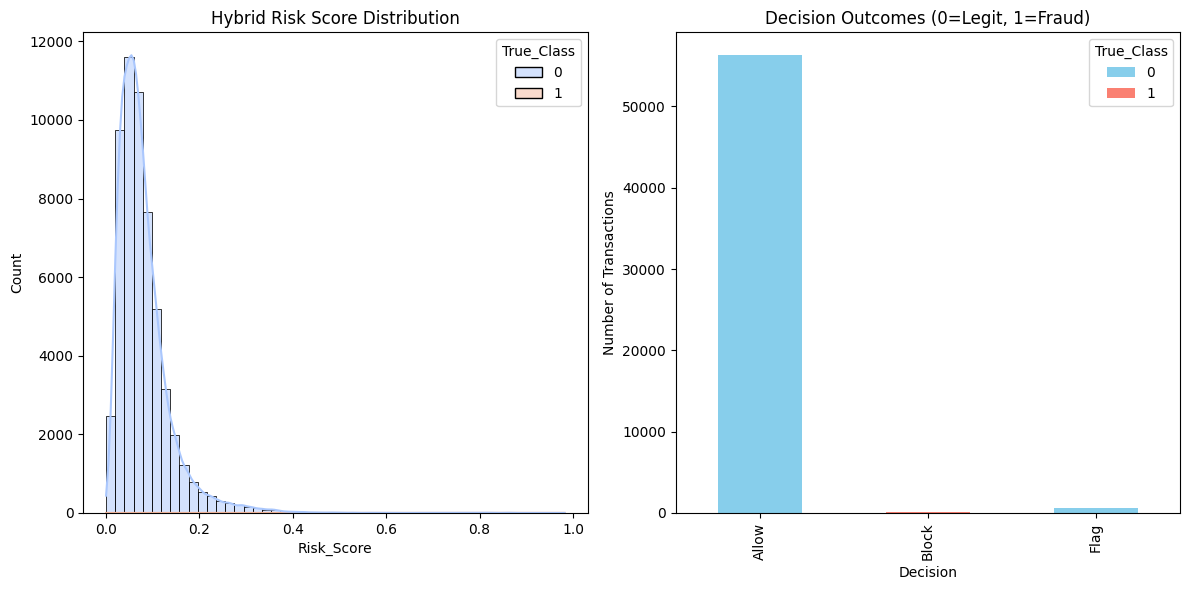

,count,Fraud_Caught,Fraud_Rate (%)
Decision,,,
Allow,56299,10,0.017762
Block,100,78,78.000000
Flag,563,10,1.776199


In [34]:
plt.figure(figsize=(12, 6))

# Plot 1: Distribution
plt.subplot(1, 2, 1)
sns.histplot(data=risk_df, x='Risk_Score', hue='True_Class', bins=50, kde=True, palette='coolwarm')
plt.title('Hybrid Risk Score Distribution')

# Plot 2: Decision Outcomes vs Truth
plt.subplot(1, 2, 2)
outcome_counts = pd.crosstab(risk_df['Decision'], risk_df['True_Class'])
outcome_counts.plot(kind='bar', stacked=True, ax=plt.gca(), color=['skyblue', 'salmon'])
plt.title('Decision Outcomes (0=Legit, 1=Fraud)')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

# Final Summary Table
summary = risk_df.groupby('Decision')['True_Class'].agg(['count', 'sum']).rename(columns={'sum': 'Fraud_Caught'})
summary['Fraud_Rate (%)'] = (summary['Fraud_Caught'] / summary['count']) * 100
display(summary)


In [35]:
from sklearn.metrics import average_precision_score, precision_recall_curve

def compute_comprehensive_metrics(y_true, y_prob, name="Model"):
    # Binary predictions at standard 0.5 threshold
    y_pred = (y_prob > 0.5).astype(int)
    
    # Calculate scores
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    
    return {
        "Model": name,
        "Precision": p,
        "Recall": r,
        "F1-Score": f1,
        "ROC-AUC": roc,
        "PR-AUC": pr_auc
    }


In [36]:
def precision_at_k(y_true, y_prob, k_percent):
    # Sort by probability descending
    df_temp = pd.DataFrame({'true': y_true, 'prob': y_prob}).sort_values(by='prob', ascending=False)
    
    # Take top k%
    k = int(len(df_temp) * k_percent)
    top_k = df_temp.iloc[:k]
    
    # Precision = (Fraud found in top k) / (Size of top k)
    return top_k['true'].mean()

# Example usage:
# p1 = precision_at_k(y_test, risk_df['Risk_Score'], 0.01)


In [37]:
def simulate_business_cost(y_true, y_prob, fp_cost=5, fn_cost=100):
    y_pred = (y_prob > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    tn, fp, fn, tp = cm.ravel()
    
    total_cost = (fp * fp_cost) + (fn * fn_cost)
    return total_cost


In [38]:
# 1. Collect metrics for all major versions
comparison_data = []

# List of models to compare (using their probabilities)
models_to_compare = [
    ("Logistic Regression", lr_model.predict_proba(X_test)[:, 1]),
    ("Random Forest", rf_model.predict_proba(X_test)[:, 1]),
    ("XGBoost", xgb_model.predict_proba(X_test)[:, 1]),
    ("Hybrid Risk System", risk_df['Risk_Score'])
]

for name, probs in models_to_compare:
    # Get standard metrics
    m = compute_comprehensive_metrics(y_test, probs, name=name)
    
    # Add Precision @ K
    m["Prec@1%"] = precision_at_k(y_test, probs, 0.01)
    
    # Add Simulated Cost
    m["Business Cost ($)"] = simulate_business_cost(y_test, probs)
    
    comparison_data.append(m)

# 2. Display Final Comparison Table
final_comparison_df = pd.DataFrame(comparison_data).set_index("Model")

print("FINAL FRAUD DETECTION SYSTEM EVALUATION")
display(final_comparison_df.style.background_gradient(cmap='RdYlGn_r', subset=['Business Cost ($)'])
                             .background_gradient(cmap='RdYlGn', subset=['PR-AUC', 'Prec@1%']))


FINAL FRAUD DETECTION SYSTEM EVALUATION


,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Prec@1%,Business Cost ($)
Model,,,,,,,
Logistic Regression,0.056258,0.908163,0.105952,0.973278,0.722471,0.154657,8365
Random Forest,0.808081,0.816327,0.812183,0.983143,0.801286,0.154657,1895
XGBoost,0.531250,0.867347,0.658915,0.973960,0.847940,0.156415,1675
Hybrid Risk System,0.651515,0.877551,0.747826,0.964066,0.727438,0.154657,1430


# Refactored Code. Use it during demonstration.

In [39]:
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix
)

# Global Configuration
SEED = 42
DATA_PATH = "/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv"
FP_COST = 5   # Cost of an annoying False Positive
FN_COST = 100 # Cost of a missed Fraud (False Negative)

def set_reproducibility(seed=SEED):
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Seeding complete (Seed: {seed})")

set_reproducibility()


✅ Seeding complete (Seed: 42)


In [40]:
from sklearn.model_selection import train_test_split

# 1. Define X and y
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Essential for imbalanced datasets
)

# 3. Scaling (Scaling AFTER split to avoid data leakage)
scaler = StandardScaler()

# We scale Time, Amount, Hour, and Amount_Log
cols_to_scale = ['Time', 'Amount', 'Hour', 'Amount_Log']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("-" * 30)
print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}")
print("-" * 30)
print("Scaling complete for 'Time', 'Amount', 'Hour', and 'Amount_Log'.")
print("Fraud distribution in Training set:")
print(y_train.value_counts(normalize=True))


------------------------------
Training Set Shape: (227845, 32)
Testing Set Shape:  (56962, 32)
------------------------------
Scaling complete for 'Time', 'Amount', 'Hour', and 'Amount_Log'.
Fraud distribution in Training set:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64


In [41]:
class EvaluationEngine:
    @staticmethod
    def precision_at_k(y_true, y_prob, k_percent):
        df = pd.DataFrame({'t': y_true, 'p': y_prob}).sort_values('p', ascending=False)
        k = int(len(df) * k_percent)
        return df.iloc[:k]['t'].mean()

    @staticmethod
    def get_metrics(y_true, y_prob, name):
        y_pred = (y_prob > 0.5).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        return {
            "Model": name,
            "PR-AUC": average_precision_score(y_true, y_prob),
            "F1-Score": f1_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred),
            "Prec@1%": EvaluationEngine.precision_at_k(y_true, y_prob, 0.01),
            "Cost ($)": (fp * FP_COST) + (fn * FN_COST)
        }


In [42]:
def train_and_evaluate_all(X_train, X_test, y_train, y_test):
    results = []
    
    # 1. Baseline: Logistic Regression
    lr = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_train, y_train)
    p_lr = lr.predict_proba(X_test)[:, 1]
    results.append(EvaluationEngine.get_metrics(y_test, p_lr, "LogReg (Balanced)"))
    
    # 2. Advanced: XGBoost
    scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss').fit(X_train, y_train)
    p_xgb = xgb.predict_proba(X_test)[:, 1]
    results.append(EvaluationEngine.get_metrics(y_test, p_xgb, "XGBoost"))
    
    # 3. Anomaly: Isolation Forest
    iso = IsolationForest(contamination=0.0017, random_state=SEED).fit(X_train)
    # Normalize to [0,1] and flip (higher = more anomalous)
    raw_iso = -iso.decision_function(X_test)
    p_iso = MinMaxScaler().fit_transform(raw_iso.reshape(-1, 1)).flatten()
    results.append(EvaluationEngine.get_metrics(y_test, p_iso, "IsoForest (Unsupervised)"))
    
    # 4. Hybrid Risk Score (Simple Alpha-Beta blend)
    # Using 0.8 XGB + 0.2 Anomaly as a robust default
    p_hybrid = (0.8 * p_xgb) + (0.2 * p_iso)
    results.append(EvaluationEngine.get_metrics(y_test, p_hybrid, "Hybrid System (Champion)"))
    
    return pd.DataFrame(results).set_index("Model")

# Execution
final_results = train_and_evaluate_all(X_train, X_test, y_train, y_test)


In [43]:
print("🏆 FINAL SYSTEM COMPARISON")
display(final_results.style.background_gradient(cmap='RdYlGn', subset=['PR-AUC', 'F1-Score', 'Prec@1%'])
                             .background_gradient(cmap='RdYlGn_r', subset=['Cost ($)']))


🏆 FINAL SYSTEM COMPARISON


,PR-AUC,F1-Score,Recall,Prec@1%,Cost ($)
Model,,,,,
LogReg (Balanced),0.722471,0.105952,0.908163,0.154657,8365
XGBoost,0.880887,0.864583,0.846939,0.154657,1555
IsoForest (Unsupervised),0.187343,0.134650,0.765306,0.112478,7005
Hybrid System (Champion),0.819547,0.854167,0.836735,0.152900,1660
